**Import Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
path_to_module = '/content/drive/MyDrive/DSML/Custom_Functions'
sys.path.append(path_to_module)

In [ ]:
from Data_Analysis_Visualization import custom_get_df_summary, custom_plot_hist, custom_plot_box, custom_plot_numeric_distribution, custom_plt_dist_plot, custom_plt_most_least10_count_plot, custom_plot_kde_distribution

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import statsmodels.api as sm
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import KFold
from statsmodels.stats.stattools import durbin_watson

from sklearn.metrics import mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import RegressionModel

#Define Problem Statement and perform Exploratory Data Analysis

**About the Business:**

&emsp;&emsp;This business case is about India’s leading education institure. It has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort.

**Business Problem**

&emsp;&emsp;The company has recently launched a feature where students/learners can come to their website and check their probability of getting into the IVY league college. This feature estimates the chances of graduate admission from an Indian perspective.

&emsp;&emsp;The company is interested in understanding what factors are important in graduate admissions and how these factors are interrelated among themselves. The company is intereseted in buidling a model that can predict the one’s chances of admission given the rest of the variables.


**Concept Used:**

- Exploratory Data Analysis
- Linear Regression

**Download the dataset**

In [ ]:
df = pd.read_csv("/content/Jamboree_Admission.csv")
df.head(4)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80


**Column Profiling**:

- Serial No. (Unique row ID)
- GRE Scores (out of 340)
- TOEFL Scores (out of 120)
- University Rating (out of 5)
- Statement of Purpose and Letter of Recommendation Strength (out of 5)
- Undergraduate GPA (out of 10)
- Research Experience (either 0 or 1)
- Chance of Admit (ranging from 0 to 1)

**Non-Graphical Univariate Analysis Summary**

- Observe shape of the data, the data types of all attributes
- Missing value detection, outlier checking, statistical summarization

In [ ]:
df_summary = custom_get_df_summary(df, print_summary=False, properties_as_columns=False)
df_summary

RangeIndex: 500 entries; Data columns (total 9 columns)
memory usage: 35.3+ KB



,Serial No.,GRE Score,TOEFL Score,University Rating,Research,SOP,LOR,CGPA,Chance of Admit
dtype,int64,int64,int64,int64,int64,float64,float64,float64,float64
Missing Counts,0,0,0,0,0,0,0,0,0
nUniques,500,49,29,5,2,9,9,184,61
Top 10 Unique Values,"1.0 (0%), 330.0 (0%), 343.0 (0%), 342.0 (0%), ...","312.0 (4%), 324.0 (4%), 316.0 (3%), 321.0 (3%)...","110.0 (8%), 105.0 (7%), 104.0 (5%), 107.0 (5%)...","3.0 (32%), 2.0 (25%), 4.0 (21%), 5.0 (14%), 1....","1.0 (56%), 0.0 (44%)","4.0 (17%), 3.5 (17%), 3.0 (16%), 2.5 (12%), 4....","3.0 (19%), 4.0 (18%), 3.5 (17%), 4.5 (12%), 2....","8.76 (1%), 8.0 (1%), 8.12 (1%), 8.45 (1%), 8.5...","0.71 (4%), 0.64 (3%), 0.73 (3%), 0.72 (3%), 0...."
Bottom 10 Unique Values,"1.0 (0%), 342.0 (0%), 341.0 (0%), 340.0 (0%), ...","293.0 (0%), 290.0 (0%), 294.0 (0%), 337.0 (0%)...","92.0 (0%), 93.0 (0%), 94.0 (0%), 95.0 (0%), 96...","1.0 (6%), 5.0 (14%), 4.0 (21%), 2.0 (25%), 3.0...","0.0 (44%), 1.0 (56%)","1.0 (1%), 1.5 (5%), 5.0 (8%), 2.0 (8%), 4.5 (1...","1.0 (0%), 1.5 (2%), 2.0 (9%), 2.5 (10%), 5.0 (...","9.65 (0%), 9.31 (0%), 8.23 (0%), 9.42 (0%), 9....","0.37 (0%), 0.39 (0%), 0.43 (0%), 0.36 (0%), 0...."
min,1.0,290.0,92.0,1.0,0.0,1.0,1.0,6.8,0.3
max,500.0,340.0,120.0,5.0,1.0,5.0,5.0,9.9,1.0
LW (1.5),1.0,290.0,92.0,1.0,0.0,1.0,1.5,6.8,0.3
Q1,125.8,308.0,103.0,2.0,0.0,2.5,3.0,8.1,0.6
Median,250.5,317.0,107.0,3.0,1.0,3.5,3.5,8.6,0.7


**Drop unnecessary column**

In [ ]:
df = df.drop('Serial No.', axis=1)

**Check potential outliers and treat**

In [ ]:
df.loc[df['LOR '] < float(df_summary.loc['LW (1.5)', 'LOR '])]

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
347,299,94,1,1.0,1.0,7.34,0,0.42


In [ ]:
df.loc[df['CGPA'] > float(df_summary.loc['UW (1.5)', 'CGPA'])]

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
143,340,120,4,4.5,4.0,9.92,1,0.97
202,340,120,5,4.5,4.5,9.91,1,0.97


In [ ]:
df.loc[df['Chance of Admit '] < float(df_summary.loc['mean-3*std', 'Chance of Admit '])]

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
58,300,99,1,3.0,2.0,6.80,1,0.36
91,299,97,3,5.0,3.5,7.66,0,0.38
92,298,98,2,4.0,3.0,8.03,0,0.34
94,303,99,3,2.0,2.5,7.66,0,0.36
374,315,105,2,2.0,2.5,7.65,0,0.39
375,304,101,2,2.0,2.5,7.66,0,0.38
376,297,96,2,2.5,2.0,7.43,0,0.34
457,295,99,1,2.0,1.5,7.57,0,0.37


Above potential outlier records appear valid.
We decide to keep the outliers for further analysis, since the outliers are not extrem hence they will not affect the analysis.

**Check for duplicte records**

In [ ]:
df.duplicated().sum()

0

**Univariate Graphical Analysis**

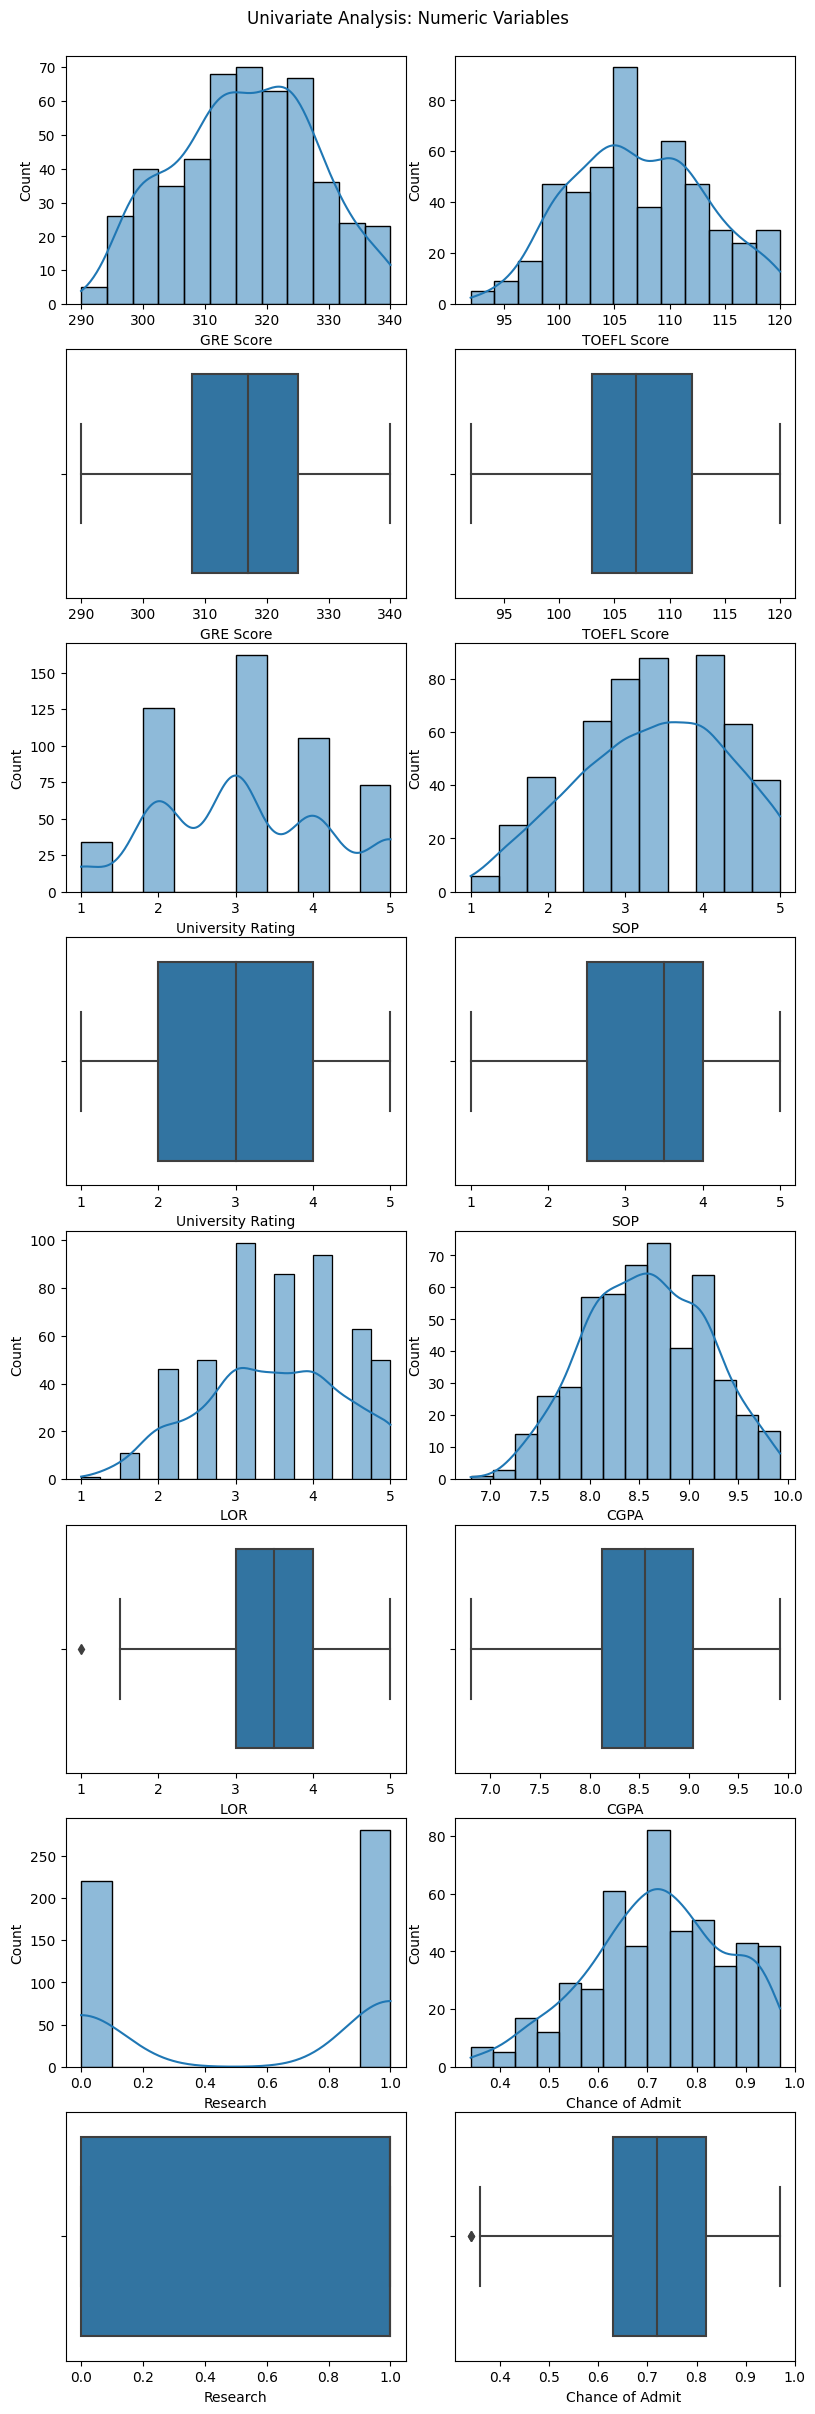

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

fig = plt.figure()
ax_list = []

j = 1
for i, num in enumerate(numeric_cols):
  ax_list.append(plt.subplot(2*len(numeric_cols), 2, j))
  ax_list.append(plt.subplot(2*len(numeric_cols), 2, j+2, sharex=ax_list[-1]))

  j= j+3 if (i+1)%2==0 else j+1

j=0
for col in numeric_cols:
  sns.histplot(ax=ax_list[j], data=df, x=col, kde=True)
  sns.boxplot(ax=ax_list[j+1], data=df, x=col)

  j += 2

fig.suptitle('Univariate Analysis: Numeric Variables')
fig.set_size_inches((8,6*len(numeric_cols)))
fig.tight_layout(pad=0.15, rect=(0, 0, 1, 0.975))

**Bivariate Analysis**

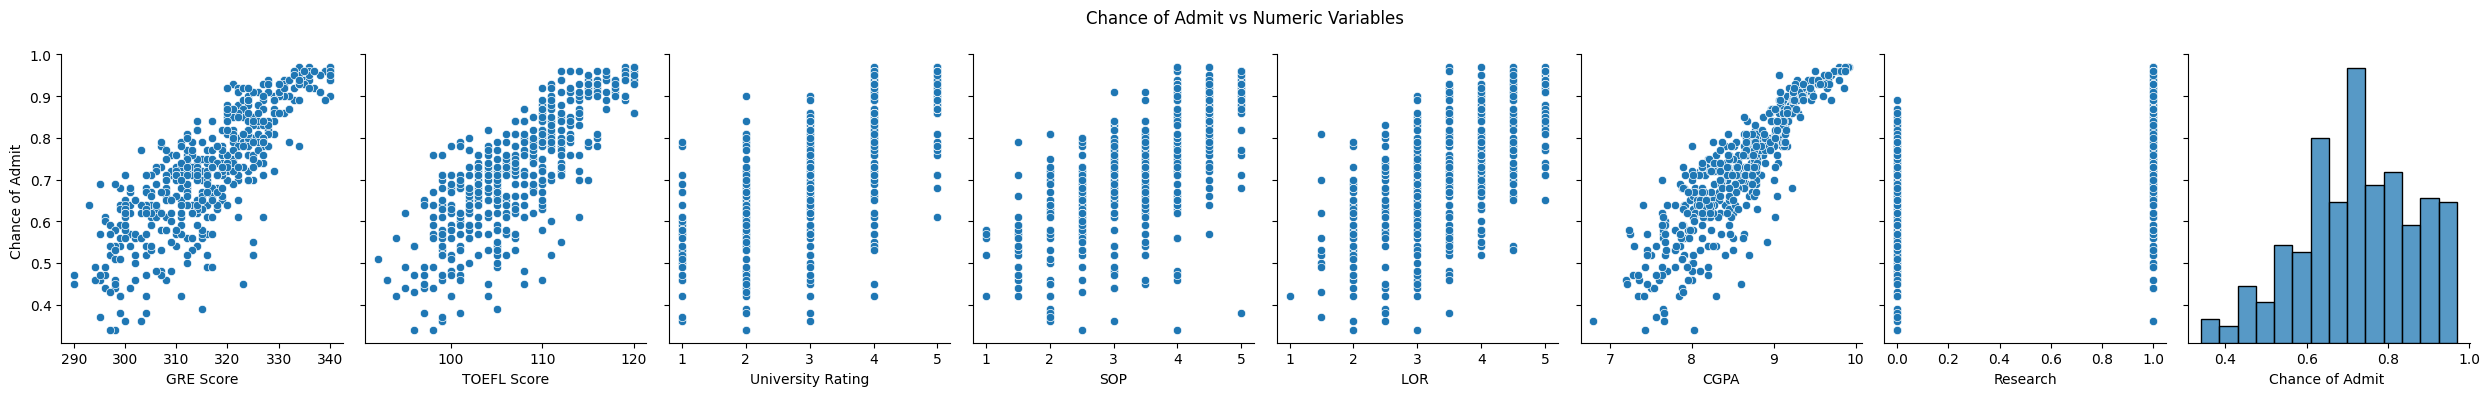

In [ ]:
pp = sns.pairplot(data=df, y_vars=['Chance of Admit '])

pp.fig.suptitle('Chance of Admit vs Numeric Variables')
pp.fig.set_size_inches((25,4))
pp.fig.tight_layout()

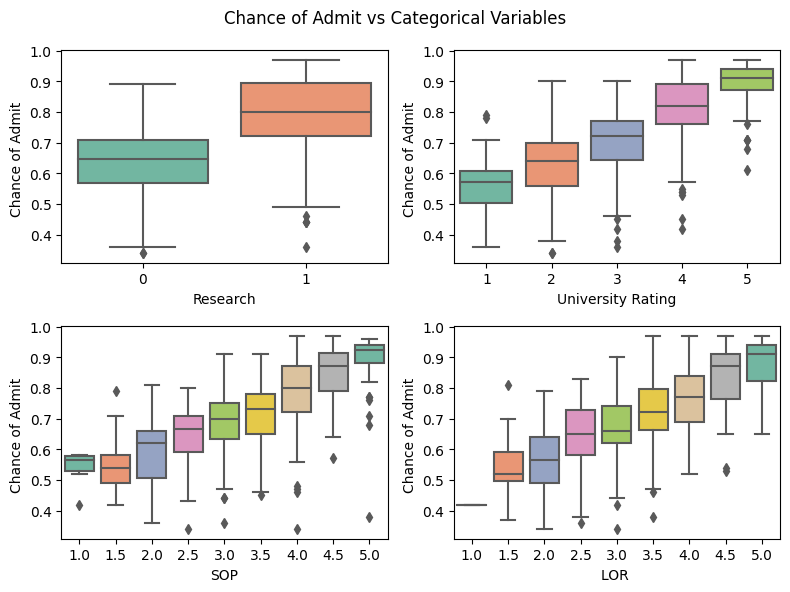

In [ ]:
fig = plt.figure()

ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 2, 3)
ax4 = plt.subplot(2, 2, 4)

sns.boxplot(ax=ax1, data=df, x='Research', y='Chance of Admit ', palette='Set2')
sns.boxplot(ax=ax2, data=df, x='University Rating', y='Chance of Admit ', palette='Set2')
sns.boxplot(ax=ax3, data=df, x='SOP', y='Chance of Admit ', palette='Set2')
sns.boxplot(ax=ax4, data=df, x='LOR ', y='Chance of Admit ', palette='Set2')

fig.suptitle('Chance of Admit vs Categorical Variables')
fig.set_size_inches((8, 6))
fig.tight_layout()

There exists a linear relationship between all the predictor variables and the dependant varaible

**Multivariate Analysis**

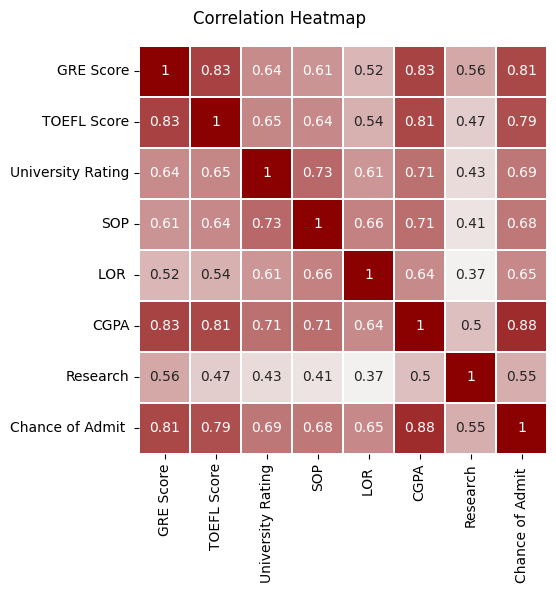

In [ ]:
fig=plt.figure()

sns.heatmap(data=df.corr(), annot=True, cmap=sns.light_palette('darkred', as_cmap=True), linewidths=0.01, linecolor='white', square=True, cbar=False)
fig.suptitle('Correlation Heatmap')
fig.set_size_inches((6, 6))
fig.tight_layout()

There exists high correlation between all the predictor variables and the dependant variable.
There is good correlatiaon between predictor variables as well. It may leed to multi-collinearity.

**Check for Multi-collinearity in Predictor variables**

In [ ]:
var_vif = pd.DataFrame(list(df.columns)[:-1], columns=['Predictor'])
var_vif['VIF'] = [variance_inflation_factor(df.drop('Chance of Admit ', axis=1).values, i) for i in range(df.drop('Chance of Admit ', axis=1).shape[1])]
var_vif

,Predictor,VIF
0,GRE Score,1308.061089
1,TOEFL Score,1215.951898
2,University Rating,20.933361
3,SOP,35.265006
4,LOR,30.911476
5,CGPA,950.817985
6,Research,2.869493


Since most of the predictors are collinear with each other, we adopt feature transformation to avoid multi-collinearity in predictor variables.

In [ ]:
df_01 = df.copy().loc[:, ['Research']]
scaler_inputs = StandardScaler()
scaler_inputs.fit(df[['GRE Score', 'TOEFL Score', 'SOP', 'LOR ', 'University Rating', 'CGPA']])
scaled_inputs = scaler_inputs.transform(df[['GRE Score', 'TOEFL Score', 'SOP', 'LOR ', 'University Rating', 'CGPA']])

df_01['GRE_TOEFL'] = scaled_inputs[:, [0,1]].sum(axis=1)
df_01['SOP_LOR'] = scaled_inputs[:, [2,3]].sum(axis=1)
df_01['UniveristyRating_CGPA'] = scaled_inputs[:, [4,5]].sum(axis=1)


In [ ]:
var_vif = pd.DataFrame(df_01.columns, columns=['Predictor'])
var_vif['VIF'] = [variance_inflation_factor(df_01, i) for i in range(len(df_01.columns))]
var_vif

,Predictor,VIF
0,Research,1.153456
1,GRE_TOEFL,3.251349
2,SOP_LOR,2.749766
3,UniveristyRating_CGPA,4.853848


Feature transformation solved the problem of multi-collinearity in the predictor vaiables. We can now add the dependant variable to newly transformed dataset.

In [ ]:
df_01['AdmitChance'] = df['Chance of Admit ']

**Check Linearity between Dependant and Predictor variables**

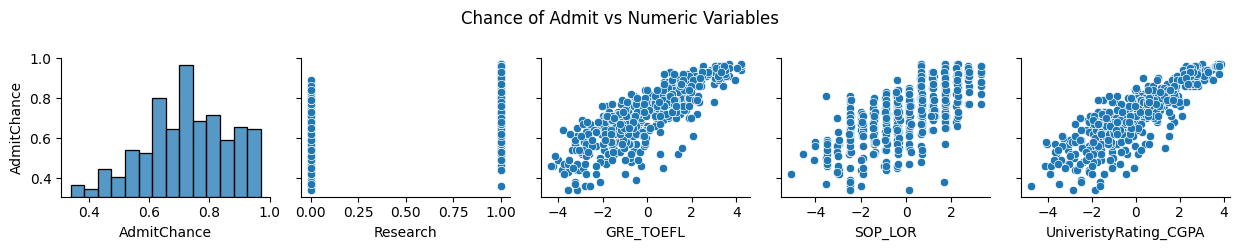

In [ ]:
pp = sns.pairplot(data=df_01[['AdmitChance', 'Research', 'GRE_TOEFL', 'SOP_LOR', 'UniveristyRating_CGPA']], y_vars=['AdmitChance'])

pp.fig.suptitle('Chance of Admit vs Numeric Variables')
pp.fig.tight_layout()

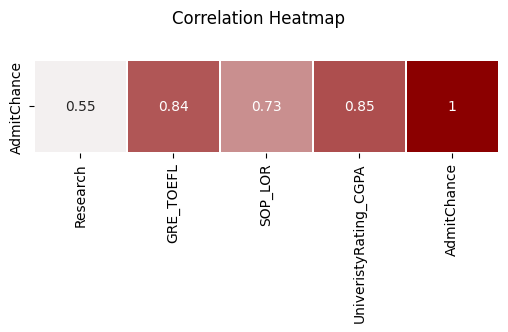

In [ ]:
fig=plt.figure()

sns.heatmap(data=df_01.corr().iloc[[-1],:], annot=True, cmap=sns.light_palette('darkred', as_cmap=True), linewidths=0.01, linecolor='white', square=True, cbar=False)
fig.suptitle('Correlation Heatmap')
fig.set_size_inches((6, 2))
# fig.tight_layout()

There exist a linear relationship bewteen each predictor and the dependant variable.

**Metrics to measure perfomance of the models**

In [ ]:
def adjusted_r2(r2, d, n):
    """
    n: no of samples
    d: no of predictors
    r2: r2 score
    """
    adj_r2 = 1 - ((1-r2)*(n-1) / (n-d-1))
    return adj_r2

def get_metrics(y_true, y_pred, d=None):
    n = y_true.shape[0]
    mse = np.sum((y_true - y_pred)**2) / n
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    score = r2_score(y_true, y_pred)
    adj_r2 = None
    if d is not None:
        adj_r2 = adjusted_r2(score, d, n)

    res = {
        "mean_absolute_error": f"{round(mae, 2):.02f}",
        "rmse": f"{round(rmse, 2):.02f}",
        "r2_score": f"{round(score, 2):.02f}",
        "adj_r2": f"{round(adj_r2, 2):.02f}"
    }
    return res

**Custom functions to build different variations of Linear Regresion**

In [ ]:

def linear_regression_summary(lr_type='LinearRegression', data=df):
  # Define the input and output variables
  X = data.iloc[:, :-1]
  y = data.iloc[:, -1]

  scaler = StandardScaler()

  # Split the data into training and testing sets
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # Split the training data into training and validation sets
  X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

  # Apply StandardScaler Transformation
  X_train_std = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
  X_val_std = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
  X_test_std = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

  if lr_type in ['ridge', 'lasso']:
    # Define the range of alpha values to test
    alphas = [0.1, 0.5, 1, 5, 10] if lr_type == 'ridge' else [0.0001, 0.001, 0.01, 0.1, 0.5, 1]

    # Initialize lists to store the results
    train_scores = []
    val_scores = []

    # Loop through each alpha value
    for alpha in alphas:
        # Fit the Ridge regression model on the training data
        if lr_type == 'ridge':
          model = Ridge(alpha=alpha).fit(X_train_std, y_train)
        else:
          model = Lasso(alpha=alpha).fit(X_train_std, y_train)

        # Predict on the training and validation data
        y_train_pred = model.predict(X_train_std)
        y_val_pred = model.predict(X_val_std)

        # Calculate the mean squared error for the training and validation data
        train_mse = mean_squared_error(y_train, y_train_pred)
        val_mse = mean_squared_error(y_val, y_val_pred)

        # Append the scores to the lists
        train_scores.append(train_mse)
        val_scores.append(val_mse)

    # Find the best alpha value based on the validation scores
    best_alpha = alphas[np.argmin(val_scores)]

    # Fit the Ridge regression model on the training data using the best alpha value
    if lr_type == 'ridge':
      model = Ridge(alpha=best_alpha).fit(X_train_std, y_train)
    elif lr_type == 'lasso':
      model = Lasso(alpha=best_alpha).fit(X_train_std, y_train)
  else:
    model = LinearRegression().fit(X_train_std, y_train)

  # Get metrics Training
  metrics_train = get_metrics(y_train, model.predict(X_train_std), X.shape[1])
  metrics_val = get_metrics(y_val, model.predict(X_val_std), X.shape[1])
  metrics_test = get_metrics(y_test, model.predict(X_test_std), X.shape[1])

  df_coef = pd.DataFrame(['Intercept'] + list(model.feature_names_in_), columns=['Predictors'])
  df_coef['Weights'] = [model.intercept_.round(3)] + list(model.coef_.round(3))
  df_coef['VIF'] = np.array([0] + [variance_inflation_factor(X_train_std.values, i) for i in range(X_train_std.shape[1])]).round(2)

  print('-'*40)
  print(f'Regression Model: {lr_type}')
  if lr_type in ['ridge', 'lasso']:
    print(f"Best alpha: {best_alpha}\n")
  else:
    print()
  print('Train Data Metrics: ')
  print(f"\tMAE: {metrics_train['mean_absolute_error']}\tRMSE: {metrics_train['rmse']}\tR2: {metrics_train['r2_score']}\tR2_adj: {metrics_train['adj_r2']}")
  print('Validation Data Metrics: ')
  print(f"\tMAE: {metrics_val['mean_absolute_error']}\tRMSE: {metrics_val['rmse']}\tR2: {metrics_val['r2_score']}\tR2_adj: {metrics_val['adj_r2']}")
  print('Test Data Metrics: ')
  print(f"\tMAE: {metrics_test['mean_absolute_error']}\tRMSE: {metrics_test['rmse']}\tR2: {metrics_test['r2_score']}\tR2_adj: {metrics_test['adj_r2']}\n")

  print('Model Parameters: ')
  print(df_coef)
  print('-'*40)

  y_train_pred = model.predict(X_train_std)
  residuals = y_train-y_train_pred

  print(f"Residuals Metrics \n\tMean: {np.array(residuals).mean():.2e} \tShapiroWilk_pval: {stats.shapiro(residuals)[1]:2e}")

  fig = plt.figure()
  ax1 = plt.subplot(2, 1, 1)
  ax2 = plt.subplot(2, 1, 2)

  sns.histplot(ax=ax1, x= residuals, kde=True)
  ax1.set_xlabel('Residuals')
  sns.scatterplot(ax=ax2, x=y_train_pred, y=residuals)
  ax2.set_xlabel('Admit Chance Predicted (Training Data)')
  ax2.set_ylabel('Residuals')

  fig.suptitle('Check Normality of Residuals and Homoscedasticity')
  # fig.set_size_inches((5, 5))
  fig.tight_layout()
  plt.plot()

  return model, X_train_std, y_train, X_val_std, y_val, X_test_std, y_test

In [ ]:
def elasticnet(data=df_01):
  # Define the predictor and response variables
  X = data.iloc[:, :-1]
  y = data.iloc[:, -1]

  # Define the number of folds
  k = 5

  # Create a KFold object
  kf = KFold(n_splits=k, shuffle=True, random_state=42)

  # Create a scaler object
  scaler = StandardScaler()

  metric_train_list = {'mean_absolute_error': [],
                  'rmse': [],
                  'r2_score': [],
                  'adj_r2': []}
  metric_val_list = {'mean_absolute_error': [],
                  'rmse': [],
                  'r2_score': [],
                  'adj_r2': []}
  metric_test_list = {'mean_absolute_error': [],
                  'rmse': [],
                  'r2_score': [],
                  'adj_r2': []}
  intercept_list = []
  coef_list = []
  residual_array = []
  y_pred_array = []

  # Loop over the folds
  for train_index, test_index in kf.split(X):
      # Split the data into training and test sets
      X_train, X_test = X.iloc[train_index], X.iloc[test_index]
      y_train, y_test = y.iloc[train_index], y.iloc[test_index]

      # Standardize the training and test data
      X_train_std = scaler.fit_transform(X_train)
      X_test_std = scaler.transform(X_test)

      # Fit the elasticNet model on the training data
      model = ElasticNetCV(cv=10, l1_ratio=[.1, .5, .7, .9, .95, .99, 1], random_state=0, max_iter=10000)
      model.fit(X_train_std, y_train)

      metrics_train = get_metrics(y_train, model.predict(X_train_std), X.shape[1])
      metric_train_list['mean_absolute_error'].append(float(metrics_train['mean_absolute_error']))
      metric_train_list['rmse'].append(float(metrics_train['rmse']))
      metric_train_list['r2_score'].append(float(metrics_train['r2_score']))
      metric_train_list['adj_r2'].append(float(metrics_train['adj_r2']))

      metrics_test = get_metrics(y_test, model.predict(X_test_std), X.shape[1])
      metric_test_list['mean_absolute_error'].append(float(metrics_test['mean_absolute_error']))
      metric_test_list['rmse'].append(float(metrics_test['rmse']))
      metric_test_list['r2_score'].append(float(metrics_test['r2_score']))
      metric_test_list['adj_r2'].append(float(metrics_test['adj_r2']))

      intercept_list.append(model.intercept_)
      coef_list.append(list(model.coef_))

      residual_array = residual_array + list(np.array(y_train) - np.array(model.predict(X_train_std)))
      y_pred_array = y_pred_array + list(model.predict(X_train_std))

  # Get metrics Training
  metrics_train = {}
  for key, val in metric_train_list.items():
    metrics_train[key] = round(np.mean(val), 2)
  metrics_test = {}
  for key, val in metric_test_list.items():
    metrics_test[key] = round(np.mean(val), 2)

  df_coef = pd.DataFrame(['Intercept'] + list(_[0].feature_names_in_), columns=['Predictors'])
  df_coef['Weights'] = [round(np.mean(intercept_list), 3)] + list(np.array(coef_list).mean(axis=0).round(3))
  df_coef['VIF'] = np.array([0] + [variance_inflation_factor(X_train_std, i) for i in range(X_train_std.shape[1])]).round(2)

  print('-'*40)
  print(f'Regression Model: ElasticNet')
  print(f"Best alpha: {model.alpha_}")
  print(f"Best l1_ratio: {model.l1_ratio_}\n")

  print()
  print('Train Data Metrics: ')
  print(f"\tMAE: {metrics_train['mean_absolute_error']}\tRMSE: {metrics_train['rmse']}\tR2: {metrics_train['r2_score']}\tR2_adj: {metrics_train['adj_r2']}")
  print('Test Data Metrics: ')
  print(f"\tMAE: {metrics_test['mean_absolute_error']}\tRMSE: {metrics_test['rmse']}\tR2: {metrics_test['r2_score']}\tR2_adj: {metrics_test['adj_r2']}\n")

  print('Model Parameters: ')
  print(df_coef)
  print('-'*40)

  print(f"Residuals Metrics \n\tMean: {np.array(residual_array).mean():.2e} \tShapiroWilk_pval: {stats.shapiro(residual_array)[1]:.2e}")

  fig = plt.figure()
  ax1 = plt.subplot(3, 1, 1)
  ax2 = plt.subplot(3, 1, 2)
  ax3 = plt.subplot(3, 1, 3)

  sns.histplot(ax=ax1, x=residual_array, kde=True)
  ax1.set_xlabel('Residuals')

  sm.qqplot(ax=ax2, data=np.array(residual_array), line='r')

  sns.scatterplot(ax=ax3, x=y_pred_array, y=residual_array)
  ax3.set_xlabel('Admit Chance Predicted (Training Data)')
  ax3.set_ylabel('Residuals')

  fig.suptitle('Check Normality of Residuals and Homoscedasticity')
  fig.set_size_inches((7, 10))
  fig.tight_layout()
  plt.plot()


##Build Linear Regression Model

**Feature importnace and selection using StasModel OLS Summary**

In [ ]:
# Load the dataset
data = sm.add_constant(df_01)

# Define the input and output variables
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the multiple linear regression model on the training data
model = sm.OLS(y_train, X_train).fit()

In [ ]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            AdmitChance   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     372.7
Date:                Wed, 14 Jun 2023   Prob (F-statistic):          1.29e-132
Time:                        16:39:19   Log-Likelihood:                 530.42
No. Observations:                 400   AIC:                            -1051.
Df Residuals:                     395   BIC:                            -1031.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.7091      0.005    131.868      0.000       0.699       0.720
Research                  0.0243      0.008      3.112      0.002       0.009       0.040
GRE_TOEFL                 0.0317      0.003      9.971      0.000       0.025       0.038
SOP_LOR                   0.0102      0.003      3.501      0.001       0.004       0.016
UniveristyRating_CGPA     0.0262      0.004      6.788      0.000       0.019       0.034
==============================================================================
Omnibus:                       76.244   Durbin-Watson:                   2.066
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              141.185
Skew:                          -1.062   Prob(JB):                     2.20e-31
Kurtosis:                       4.990   Cond. No.                         8.29
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Assuming Significance Level=0.01 (99% Confidence Level)

- All the predictors have significant importance in predicting the dependant variable.
- High F-statistic highlight impotance of all the predictors in the prediction model.


**Linear Regression Model**

 Check
 - performance metrics
 - model parameters
 - assumptions

----------------------------------------
Regression Model: LinearRegression

Train Data Metrics: 
	MAE: 0.05	RMSE: 0.07	R2: 0.78	R2_adj: 0.78
Validation Data Metrics: 
	MAE: 0.04	RMSE: 0.06	R2: 0.81	R2_adj: 0.80
Test Data Metrics: 
	MAE: 0.05	RMSE: 0.06	R2: 0.80	R2_adj: 0.79

Model Parameters: 
              Predictors  Weights   VIF
0              Intercept    0.727  0.00
1               Research    0.017  1.50
2              GRE_TOEFL    0.058  3.66
3                SOP_LOR    0.022  2.60
4  UniveristyRating_CGPA    0.044  5.15
----------------------------------------
Residuals Metrics 
	Mean: -1.09e-16 	ShapiroWilk_pval: 1.056126e-09


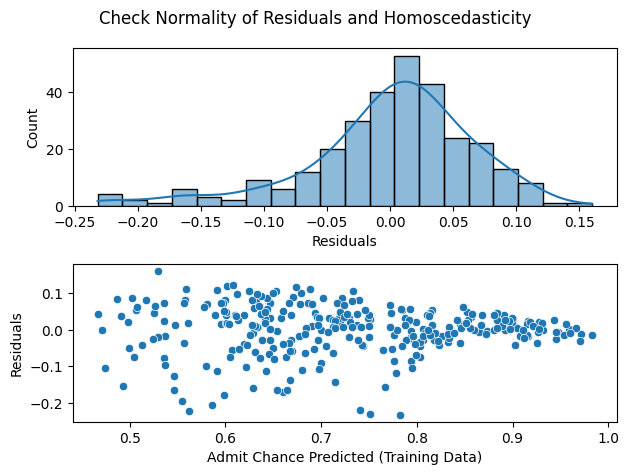

In [ ]:
_ = linear_regression_summary(lr_type='LinearRegression', data=df_01)

**Linear Regression Model with Ridge Regularization**

 Check
 - performance metrics
 - model parameters and hyper parameters
 - assumptions

----------------------------------------
Regression Model: ridge
Best alpha: 0.1

Train Data Metrics: 
	MAE: 0.05	RMSE: 0.07	R2: 0.78	R2_adj: 0.78
Validation Data Metrics: 
	MAE: 0.04	RMSE: 0.06	R2: 0.81	R2_adj: 0.80
Test Data Metrics: 
	MAE: 0.05	RMSE: 0.06	R2: 0.80	R2_adj: 0.79

Model Parameters: 
              Predictors  Weights   VIF
0              Intercept    0.727  0.00
1               Research    0.017  1.50
2              GRE_TOEFL    0.058  3.66
3                SOP_LOR    0.022  2.60
4  UniveristyRating_CGPA    0.044  5.15
----------------------------------------
Residuals Metrics 
	Mean: -1.10e-16 	ShapiroWilk_pval: 1.044363e-09


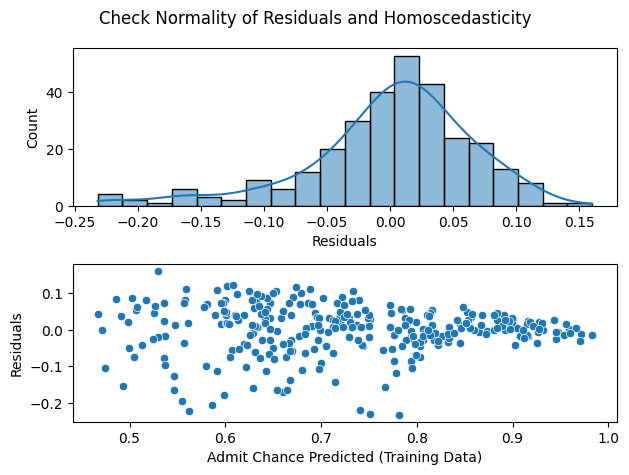

In [ ]:
_ = linear_regression_summary(lr_type='ridge', data=df_01)


**Linear Regression Model with Lasso Regularization**

 Check
 - performance metrics
 - model parameters and hyper parameters
 - assumptions

----------------------------------------
Regression Model: lasso
Best alpha: 0.01

Train Data Metrics: 
	MAE: 0.05	RMSE: 0.07	R2: 0.78	R2_adj: 0.77
Validation Data Metrics: 
	MAE: 0.04	RMSE: 0.06	R2: 0.81	R2_adj: 0.80
Test Data Metrics: 
	MAE: 0.05	RMSE: 0.06	R2: 0.80	R2_adj: 0.79

Model Parameters: 
              Predictors  Weights   VIF
0              Intercept    0.727  0.00
1               Research    0.011  1.50
2              GRE_TOEFL    0.054  3.66
3                SOP_LOR    0.016  2.60
4  UniveristyRating_CGPA    0.045  5.15
----------------------------------------
Residuals Metrics 
	Mean: -1.08e-16 	ShapiroWilk_pval: 2.929331e-12


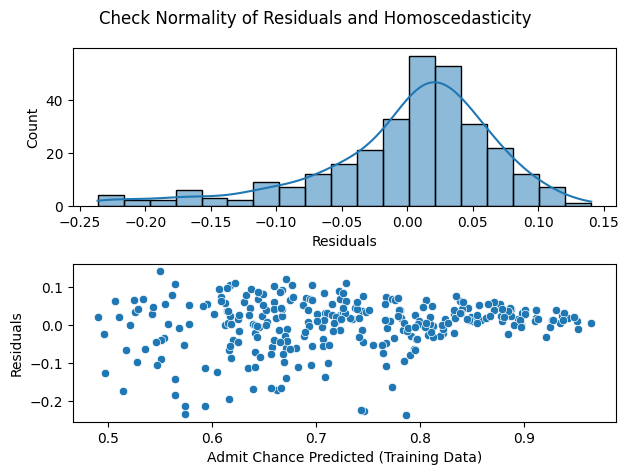

In [ ]:

_ = linear_regression_summary(lr_type='lasso', data=df_01)

**Linear Regression Model with ElasticNet Regularization**

 Check
 - performance metrics
 - model parameters and hyper parameters
 - assumptions

----------------------------------------
Regression Model: ElasticNet
Best alpha: 0.010968104038838552
Best l1_ratio: 0.1


Train Data Metrics: 
	MAE: 0.05	RMSE: 0.06	R2: 0.79	R2_adj: 0.79
Test Data Metrics: 
	MAE: 0.05	RMSE: 0.06	R2: 0.78	R2_adj: 0.77

Model Parameters: 
              Predictors  Weights   VIF
0              Intercept    0.722  0.00
1               Research    0.012  1.44
2              GRE_TOEFL    0.054  3.46
3                SOP_LOR    0.017  2.75
4  UniveristyRating_CGPA    0.054  4.72
----------------------------------------
Residuals Metrics 
	Mean: -4.00e-18 	ShapiroWilk_pval: 8.09e-30


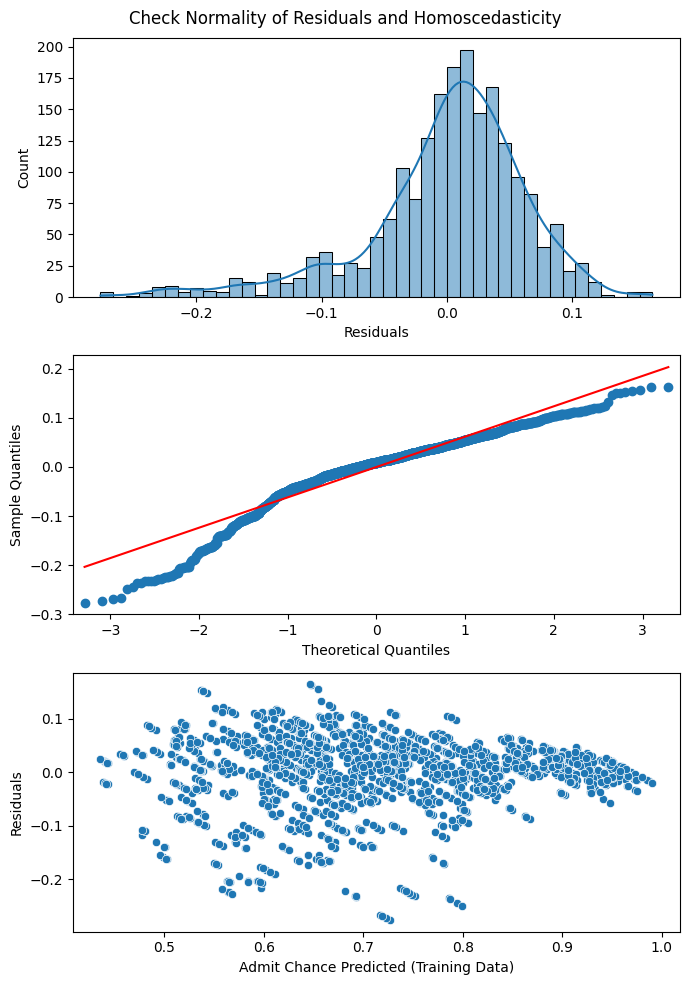

In [ ]:
elasticnet(data=df_01)

**Testing the assumptions: Remarks**

Linearity:
- There is linear relationship between the dependant variable and the predictor variables

No Multi-collinearity:
- Since VIF vales of all the predictor varibles are less than 5, there is no multi-collinearity

Mean of Residuals:
- The mean of reciduals is nearly zero

Normality of Residuals:
- Low p_value of ShapiroWilk test states the residual distribution is not normal
- Visually the distribution is left skewed, which means model predicts high values for some datapoints

Homoscedasticity:
- Residual vs predicted values graph shows that there is some amount of heteroscedasticity, however it is very low
- Some amount of heteroscedasticity exists only for the values predicted more than 0.85

#**Insights and Recommendation**
- There was high multi-collinearity in the predictor variables. Featrue transformation fixed the probelm of multi-collinearity.
However, the transformation and merging of the variables need more exploration
- Most of the Linear Regression Assumptions are satisfied with some exceptions like linearity of residuals and heteroscedasticity. It is observed that the violation of these assumptions is not serious. We can use this model for the specified purpose. However, use of suitable ML model must be explored
- All the variations of Linear Regression model yield more or less same performance
- Final model accuracy was around 80%. Consider adding relevant predictors (eg. State of Residence) that are ommited from this analysis.
- It is observed that University Rating, CGPA, GRE score and TOEFL score are the most important predictors to decide one`s chances of admission
- The SOP and LOR are important to some extent
- Research has least impact on chances of admission